# Credit Card Fraud Detection
## Phase 2: Data Preprocessing

In this phase, we apply leakage-safe preprocessing. We determine our train/val/test splits and scale our numerical features (`Amount` and `Time`). Most importantly, we ensure that the Autoencoder training set contains ONLY legitimate transactions, and that `Class` is not part of the input features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import sys

# Add src to path
sys.path.append('../')
from src.preprocessing import split_data_anomaly_detection, preprocess_features, load_config

# Load config
config = load_config('../configs/config.yaml')
print("Configuration loaded:", config['data'])

Configuration loaded: {'raw_path': 'data/creditcard.csv', 'subset_path': 'data/creditcard_subset_30k.csv', 'test_size': 0.2, 'val_size': 0.2}


### 1. Load Dataset
We load the subset dataset constructed in Phase 1.

In [2]:
df = pd.read_csv('../' + config['data']['subset_path'])
print(f"Total shape: {df.shape}")
print(f"Total Fraud: {df['Class'].sum()}")

Total shape: (30492, 31)
Total Fraud: 492


### 2. Splitting Strategy
We split the data so that:
1. The Autoencoder training set contains 60% of all legitimate transactions and 0 fraud transactions.
2. The Validation set gets 20% of legitimate transactions and 50% of the fraud transactions.
3. The Test set gets 20% of legitimate transactions and 50% of the fraud transactions.

In [3]:
train_df, val_df, test_df = split_data_anomaly_detection(
    df, 
    val_size=config['data']['val_size'], 
    test_size=config['data']['test_size'], 
    random_state=config['random_seed']
)

print(f"Train set shape: {train_df.shape} | Fraud count: {train_df['Class'].sum()}")
print(f"Val set shape: {val_df.shape}   | Fraud count: {val_df['Class'].sum()}")
print(f"Test set shape: {test_df.shape}  | Fraud count: {test_df['Class'].sum()}")

Train set shape: (18000, 31) | Fraud count: 0
Val set shape: (6246, 31)   | Fraud count: 246
Test set shape: (6246, 31)  | Fraud count: 246


### 3. Feature Scaling
We apply `RobustScaler` to `Amount` and `Time` features. The `V1-V28` features are already PCA transformed so we leave them unchanged. We fit the scaler strictly on the training set to prevent data leakage.

In [4]:
(X_train, y_train), (X_val, y_val), (X_test, y_test), (scaler_time, scaler_amount) = preprocess_features(train_df, val_df, test_df)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (18000, 30), y_train shape: (18000,)
X_val shape: (6246, 30), y_val shape: (6246,)
X_test shape: (6246, 30), y_test shape: (6246,)


### 4. Verification
Let's verify that the distributions of the scaled features look reasonable and that `Class` is absent from X features.

First row of X_train (features only, no class label):
[ 0.43648097 -0.59057209  0.9468807  -1.28745244 -1.09581127  1.10191243
 -0.30318473  0.63950923  0.25074623 -0.22247039 -0.12924562 -0.83574274
  0.35408826  0.19543758  0.55499002 -1.28612716  0.30156006 -0.99928699
  0.77865347  0.45816181 -0.17096156  0.48862478  1.52540123 -0.21561568
 -1.2730527  -0.51899305  0.84833162  0.02080616  0.24405883 -0.26495542]


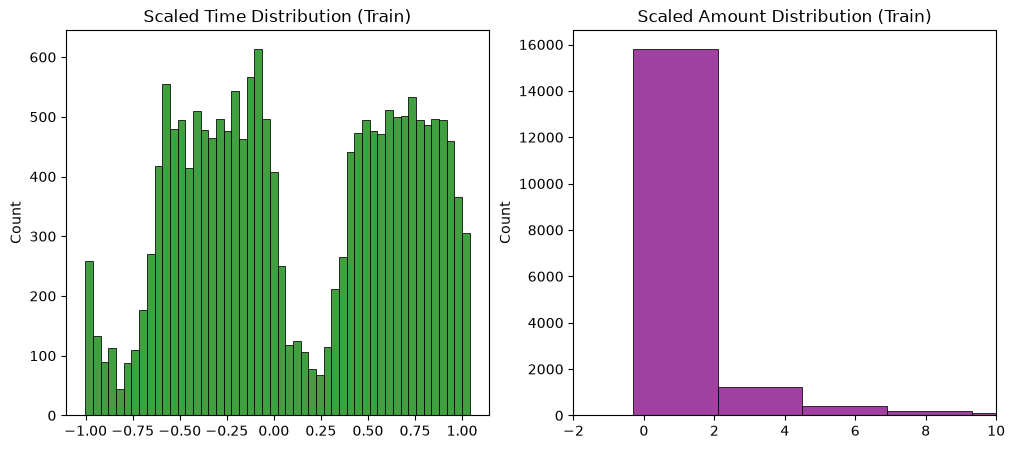

In [5]:
print("First row of X_train (features only, no class label):")
print(X_train[0])

# Plotting scaled distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(X_train[:, 0], bins=50, ax=axes[0], color='green')
axes[0].set_title('Scaled Time Distribution (Train)')

sns.histplot(X_train[:, -1], bins=50, ax=axes[1], color='purple')
axes[1].set_title('Scaled Amount Distribution (Train)')
axes[1].set_xlim(-2, 10) # Zoom in to see the bulk of the data
plt.show()